In [0]:

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn import metrics
import scipy.optimize as opt
from sklearn.metrics import accuracy_score

In [0]:
df = pd.read_csv("land_type.csv")
x = df.drop("land_type", axis=1).values
y = df['land_type']

### Plotting data

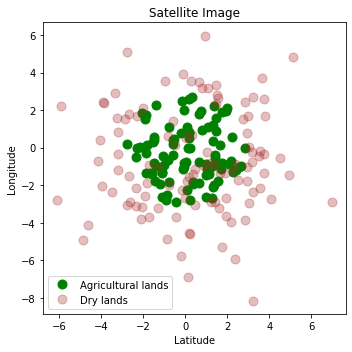

In [0]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    
ax.plot(x[y == 1, 0], x[y == 1, 1], 'o',c='green', markersize=9,label='Agricultural lands')
ax.plot(x[y == 0, 0], x[y == 0, 1], 'o',c='brown', markersize=9,label='Dry lands', alpha=0.3)
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
ax.set_title('Satellite Image')

ax.legend()
plt.tight_layout()
plt.show() 

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


Accuracy= 0.91


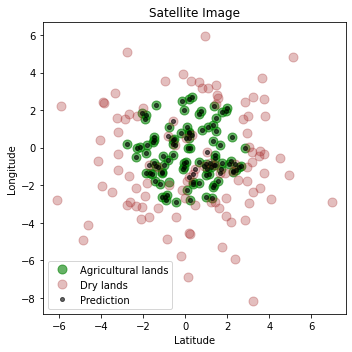

In [0]:
#c = 9999999999999990
c = 1e15
degree = 10
lr = LogisticRegression(C=c, max_iter=16000)
x1 = PolynomialFeatures(degree).fit_transform(x)
lr.fit(x1, y)
yp = lr.predict(x1)

validation_accuracy = accuracy_score(y, yp)

print("Accuracy=",validation_accuracy)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.plot(x[y == 1, 0], x[y == 1, 1], 'o',c='green',alpha = 0.6, markersize=9,label='Agricultural lands')
ax.plot(x[y == 0, 0], x[y == 0, 1], 'o',c='brown', markersize=9,label='Dry lands', alpha=0.3)
ax.plot(x[yp == 1, 0], x[yp == 1, 1], 'o',c='black', alpha = 0.6, markersize=4,label='Prediction')

ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
ax.set_title('Satellite Image')

ax.legend()
plt.tight_layout()
plt.show() 

In [0]:
def plot_boundary(x, y, model, title, ax, plot_data=True, fill=True, color='Greens'):
    
    
    if plot_data:
        # PLOT DATA
        ax.scatter(x[y==1,0], x[y==1,1], c='green')
        ax.scatter(x[y==0,0], x[y==0,1], c='brown')
    
    # CREATE MESH
    interval = np.arange(min(x.min(), y.min()),max(x.max(), y.max()),0.01)
    n = np.size(interval)
    x1, x2 = np.meshgrid(interval, interval)
    x1 = x1.reshape(-1,1)
    x2 = x2.reshape(-1,1)
    xx = np.concatenate((x1, x2), axis=1)

    # PREDICT ON MESH POINTS
    degree = 10
    xxpoly = PolynomialFeatures(degree).fit_transform(xx)
    yy = model.predict(xxpoly)    
    yy = yy.reshape((n, n))

    # PLOT DECISION SURFACE
    x1 = x1.reshape(n, n)
    x2 = x2.reshape(n, n)
    if fill:
        ax.contourf(x1, x2, yy, alpha=0.5, cmap=color)
    else:
        ax.contour(x1, x2, yy, alpha=0.5, cmap=color)
    
    # LABEL AXIS, TITLE
    ax.set_title(title)
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Longitude')
    
    return ax

In [0]:
def fit_and_plot_dt(x, y, c, title, ax, plot_data=True, fill=True, color='Blues'):

    lreg = LogisticRegression(C=c, max_iter=6000)

    degree = 10
    
    x1 = PolynomialFeatures(degree).fit_transform(x)
    lreg.fit(x1, y)

    # PLOT DECISION TREE BOUNDARY
    ax = plot_boundary(x, y, lreg, title, ax, plot_data, fill, color)
    
    return ax

In [0]:
# npoints = 200 
# data = np.random.multivariate_normal([0, 0], np.eye(2) * 5, size=npoints)
# data = np.hstack((data, np.zeros((npoints, 1))))

# data[data[:, 0]**2 + data[:, 1]**2 < 3**2, 2] = np.random.choice([0, 1], len(data[data[:, 0]**2 + data[:, 1]**2 < 3**2]), p=[0.2, 0.8])

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


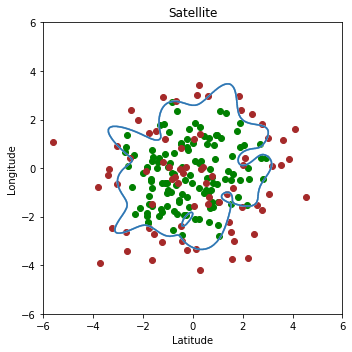

In [0]:
#Variance comparison between simple and complex models

fig, ax = plt.subplots(figsize=(5, 5))
d = 1e15
new_data = np.random.multivariate_normal([0, 0], np.eye(2) * 3, size=200)
new_data = np.hstack((new_data, np.zeros((200, 1))))
new_data[new_data[:, 0]**2 + new_data[:, 1]**2 < 3**2, 2] = np.random.choice([0, 1], len(new_data[new_data[:, 0]**2 + new_data[:, 1]**2 < 3**2]), p=[0.2, 0.8])
x = new_data[:, :-1]
y = new_data[:, -1]
ax = fit_and_plot_dt(x, y, d, 'Satellite',ax, plot_data=True, fill=False) 
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

plt.tight_layout()
plt.show() 